In [1]:
import mne
import matplotlib.pyplot as plt
import numpy as np
import os 
import sys

In [2]:

# Charger le fichier EEG 
raw = mne.io.read_raw_edf("D:/EEG/raw/GR108/210826e-a.edf", preload=True) 

# Afficher les infos
raw.info


Extracting EDF parameters from D:\EEG\raw\GR108\210826e-a.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 8204031  =      0.000 ... 32046.996 secs...


C:\Users\Dessalines\AppData\Local\Temp\ipykernel_19264\219918687.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf("D:/EEG/raw/GR108/210826e-a.edf", preload=True)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG Fp2, EEG C3, EEG C4, EEG T3, EEG T4, EEG O1, EEG ...
 chs: 38 EEG
 custom_ref_applied: False
 highpass: 0.2 Hz
 lowpass: 100.0 Hz
 meas_date: 2021-08-26 22:01:34 UTC
 nchan: 38
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: 220251GR, sex: 1, first_name: GELY, last_name: ROBERT, birthday: 1951-02-22>
>

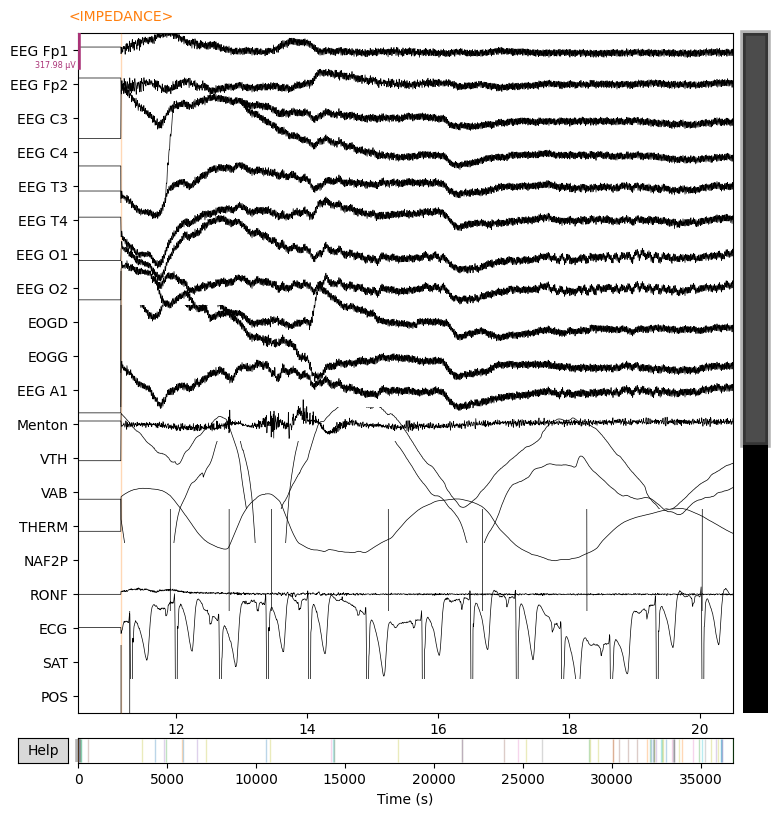

In [23]:
# Afficher le plot
raw.plot(n_channels=20, start=10.5 , duration=10, scalings='auto', show=False)


In [3]:
print(raw.ch_names)


['EEG Fp1', 'EEG Fp2', 'EEG C3', 'EEG C4', 'EEG T3', 'EEG T4', 'EEG O1', 'EEG O2', 'EOGD', 'EOGG', 'EEG A1', 'Menton', 'VTH', 'VAB', 'NAF2P', 'RONF', 'ECG', 'SAT', 'POS', 'PTT', 'PCO2', 'TEMP', 'FC', 'Pouls', 'EEG F3', 'EEG F4', 'EEG Cz', 'EEG F7', 'EEG F8', 'EEG T5', 'EEG P3', 'EEG Pz', 'EEG P4', 'EEG T6', 'JAMBD', 'SLI', 'THERM', 'CPAP']


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


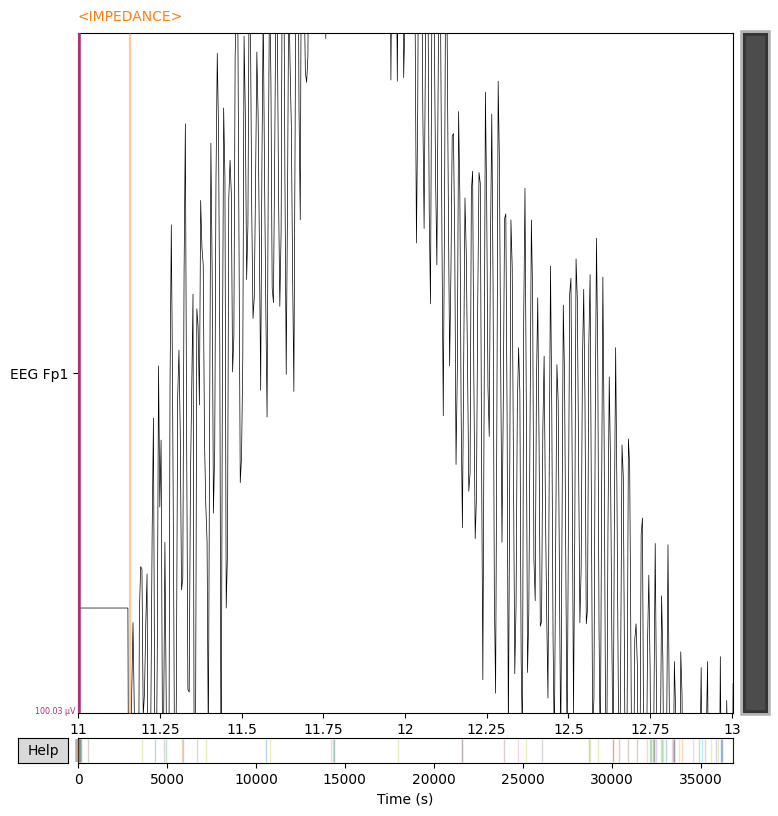

In [25]:
# Si on affiche un seul canal...
channel_name = 'EEG Fp1'

# Extraire uniquement ce canal
raw_single_channel = raw.copy().pick_channels([channel_name])

# Plot
raw_single_channel.plot(start=11, duration=2, scalings='auto', show=False)


Extracting EDF parameters from D:\EEG\raw\AE129\AE129_231121C-A.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9428991  =      0.000 ... 36831.996 secs...


C:\Users\Dessalines\AppData\Local\Temp\ipykernel_2952\554605065.py:3: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf("D:/EEG/raw/AE129/AE129_231121C-A.edf", preload=True)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


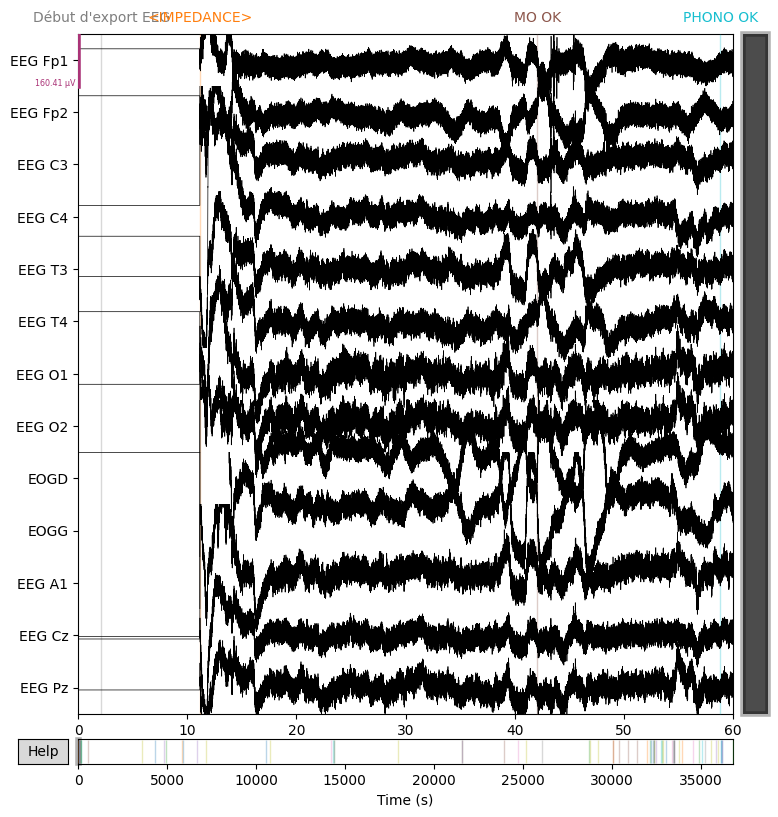

In [26]:
# Ne garder que les canaux eegs

raw = mne.io.read_raw_edf("D:/EEG/raw/AE129/AE129_231121C-A.edf", preload=True) 
eeg_channels = [ch for ch in raw.ch_names if ch.startswith('EEG ') or ch.startswith('EOG')]
raw_eeg = raw.copy().pick_channels(eeg_channels)

# Plot
raw_eeg.plot(n_channels=len(raw_eeg.ch_names),start= 0, duration=60, scalings='auto', show=False)



### Preprocessing: Prétraitement des artéfacts avec ICA

-> Demander à Aude son script de preprocessing
-> Pour l'instant ce qu'on fait c'est qu'on applique ICA pour séparer les sources indépendantes dans le signal brut pour isoler et supprimer les artefacts:
- On apprend un modèle pour décomposer le signal EEG en composantes indépendantes
- On apprend une matrice de séparation qui approxime les sources d'origine (neurales, oculaires, cardiaques, etc.).
- On corrèle les composantes ICA avec le signal EOG -> repère celles dominées par les artefacts oculaires.
- On repère les composantes avec une activité périodique correspondant à l'ECG
- On marque les composantes EOG/ECG like à supprimer
- On reconstruit le signal en supprimant les composantes ICA indésirables

In [27]:
# Visualiser un segment long (e.g. 2 minutes)
from preprocessing import preprocess_eeg_file
from mne.io import read_raw_fif

edf_path = "../data/raw/AE129/AE129_231121C-A.edf"
preprocess_eeg_file(edf_path)


Extracting EDF parameters from c:\Users\Dessalines\Desktop\Cerco_studies\data\raw\AE129\AE129_231121C-A.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9428991  =      0.000 ... 36831.996 secs...


c:\Users\Dessalines\Desktop\Cerco_studies\src\preprocessing.py:15: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(file_path, preload=True)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 845 samples (3.301 s)



[Parallel(n_jobs=1)]: Done  13 out of  13 | elapsed:    2.5s finished


Fitting ICA to data using 13 channels (please be patient, this may take a while)
Selecting by explained variance: 13 components
Fitting ICA took 109.0s.
Using EOG channel: EOGD
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2560 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidt

[Parallel(n_jobs=1)]: Done  13 out of  13 | elapsed:    2.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.1s finished


Applying ICA to Raw instance
    Transforming to ICA space (13 components)
    Zeroing out 1 ICA component
    Projecting back using 13 PCA components
Writing c:\Users\Dessalines\Desktop\Cerco_studies\notebooks\data\preprocessed\AE129_231121C-A_eeg_cleaned_raw.fif
Closing c:\Users\Dessalines\Desktop\Cerco_studies\notebooks\data\preprocessed\AE129_231121C-A_eeg_cleaned_raw.fif
[done]
 AE129_231121C-A prétraité et sauvegardé dans data/preprocessed\AE129_231121C-A_eeg_cleaned_raw.fif


Visu

Opening raw data file ../data/preprocessed/AE129_231121C-A_eeg_cleaned_raw.fif...
Isotrak not found
    Range : 0 ... 9428991 =      0.000 ... 36831.996 secs
Ready.
Reading 0 ... 9428991  =      0.000 ... 36831.996 secs...


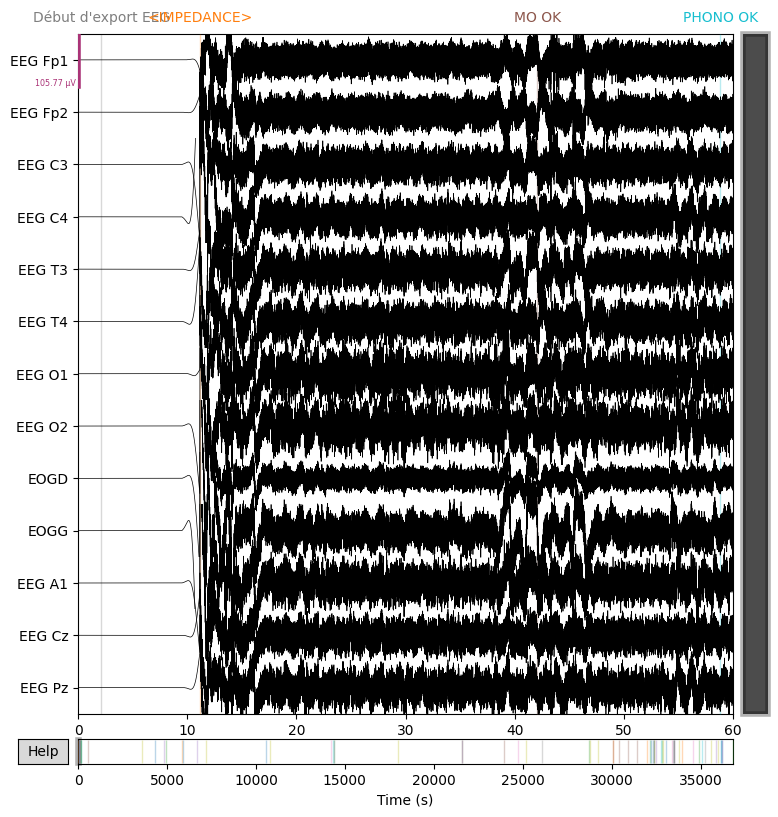

In [27]:
cleaned_path = "../data/preprocessed/AE129_231121C-A_eeg_cleaned_raw.fif"
raw_clean = read_raw_fif(cleaned_path, preload=True)

raw_clean.plot(duration=60, start=0, n_channels=20, scalings='auto', show=False)


In [29]:
raw_clean.ch_names

['EEG Fp1',
 'EEG Fp2',
 'EEG C3',
 'EEG C4',
 'EEG T3',
 'EEG T4',
 'EEG O1',
 'EEG O2',
 'EOGD',
 'EOGG',
 'EEG A1',
 'EEG Cz',
 'EEG Pz']

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


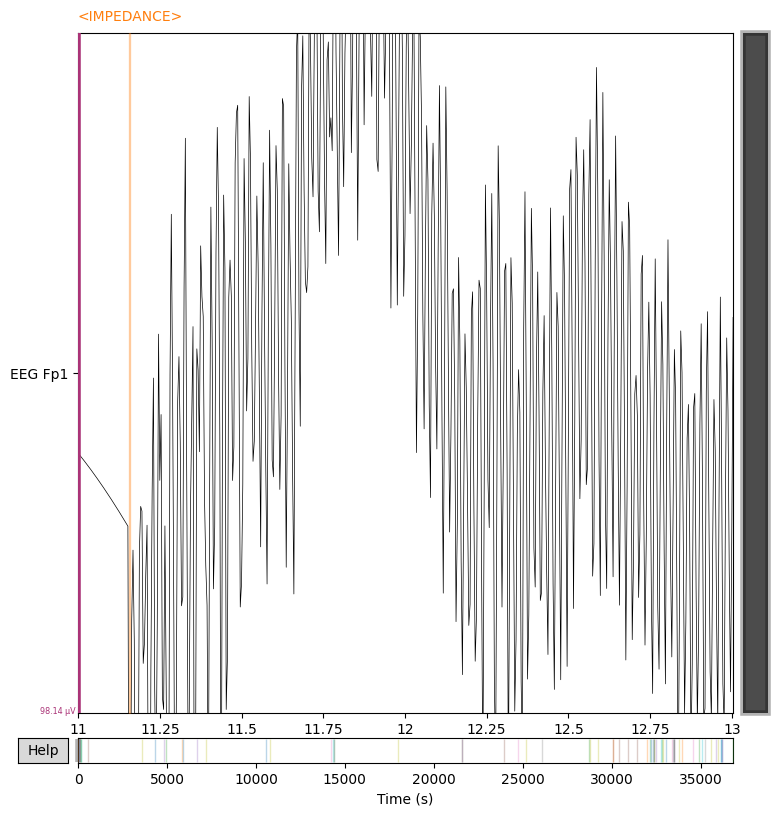

In [28]:
channel_name = 'EEG Fp1' 

# Extraire le canal
raw_single_channel = raw_clean.copy().pick_channels([channel_name])

# Visualisation
raw_single_channel.plot(start=11, duration=2, scalings='auto', show=False)


## #2e preprocessing avec recommandations de Siwar :

### REM identification

#### Via annotation .txt

Question : Les annotations sont basées sur les enregistrements vidéos ? Si, non comment ont été déterminés les REM ?

Remarque : Need convention de nommage (nom_precis.edf = nom_precis.txt ==> nom_precis.fif) pour pouvoir associer les phases REM des fichiers .txt aux signaux des fichiers .fif dont le nom se basse sur les fichiers brut .edf

In [1]:
import os
import glob

def standardize_txt_filenames(root_dir):
    edf_files = glob.glob(os.path.join(root_dir, "**", "*.edf"), recursive=True)

    for edf_path in edf_files:
        folder = os.path.dirname(edf_path)
        base_name = os.path.splitext(os.path.basename(edf_path))[0]

        # Trouver tous les .txt dans le même dossier
        txt_files = glob.glob(os.path.join(folder, "*.txt"))

        for txt_path in txt_files:
            new_path = os.path.join(folder, f"{base_name}hypnoEXP.txt")

            # Évite de renommer un fichier déjà bien nommé
            if os.path.basename(txt_path) != f"{base_name}hypnoEXP.txt":
                print(f"Renommage : {os.path.basename(txt_path)} → {base_name}hypnoEXP.txt")
                os.rename(txt_path, new_path)

standardize_txt_filenames("D:/EEG/raw")


Renommage : marre gilleshypnoEXP.txt → MG16hypnoEXP.txt
Renommage : MG16hypnoEXP.txt → marre gilleshypnoEXP.txt


Ici on identifie à l'aide du fichier .txt les zones REM du signal. 
On les coupes et on concatène en un seul fichier .fif

==> Question : Pensez-vous que c'est une bonne pratique ? 

In [3]:
import sys
import os

src_path = os.path.abspath("../src")
if src_path not in sys.path:
    sys.path.append(src_path)


from segment_rem import segment_all_rem

segment_all_rem(
    preprocessed_dir="../data/preprocessed",
    annot_root="D:/EEG/raw",
    save_dir="D:/EEG/rem_segments"
)



Opening raw data file ../data/preprocessed\200924e-aex_0001_eeg_cleaned_raw.fif...
Isotrak not found
    Range : 0 ... 14591 =      0.000 ...    56.996 secs
Ready.
Reading 0 ... 14591  =      0.000 ...    56.996 secs...
 Aucun fichier d'annotation trouvé pour 200924e-aex_0001
 Fichier déjà existant pour 210826e-a, on saute.
 Fichier déjà existant pour 220420d-b, on saute.
Opening raw data file ../data/preprocessed\230407d-aex_0000_eeg_cleaned_raw.fif...
Isotrak not found
    Range : 0 ... 8703 =      0.000 ...    33.996 secs
Ready.
Reading 0 ... 8703  =      0.000 ...    33.996 secs...
 Aucun fichier d'annotation trouvé pour 230407d-aex_0000
 Fichier déjà existant pour 230413c-b, on saute.
 Fichier déjà existant pour 230426e-a, on saute.
 Fichier déjà existant pour 230614e-a, on saute.
 Fichier déjà existant pour 230823e-b, on saute.
 Fichier déjà existant pour 230927D-B, on saute.
 Fichier déjà existant pour 230929B-B, on saute.
 Fichier déjà existant pour 231004E-A, on saute.
 Fichie

Visualisation de ces fichiers

Opening raw data file D:/EEG/rem_segments/210826e-a_REM_raw.fif...
Isotrak not found
    Range : 4485120 ... 4876850 =  17520.000 ... 19050.195 secs
Ready.
Reading 0 ... 391730  =      0.000 ...  1530.195 secs...


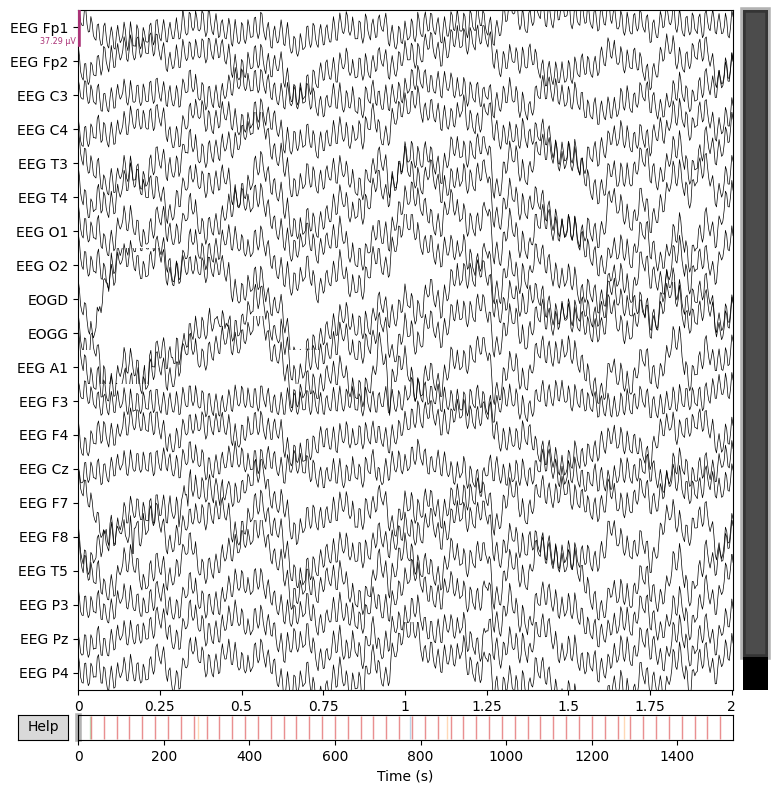

In [9]:
from mne.io import read_raw_fif
rem_segmt_path = "D:/EEG/rem_segments/210826e-a_REM_raw.fif"
rem_segmt = read_raw_fif(rem_segmt_path, preload=True)

rem_segmt.plot(duration=2, start=0, n_channels=20, scalings='auto', show=False)


### Filtration sur différentes gammes de fréquences (alpha, beta, gamma...)

Opening raw data file ../data/preprocessed/200924e-aex_0001_eeg_cleaned_raw.fif...
Isotrak not found
    Range : 0 ... 14591 =      0.000 ...    56.996 secs
Ready.
Reading 0 ... 14591  =      0.000 ...    56.996 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 423 samples (1.652 s)



[Parallel(n_jobs=1)]: Done  13 out of  13 | elapsed:    0.0s finished


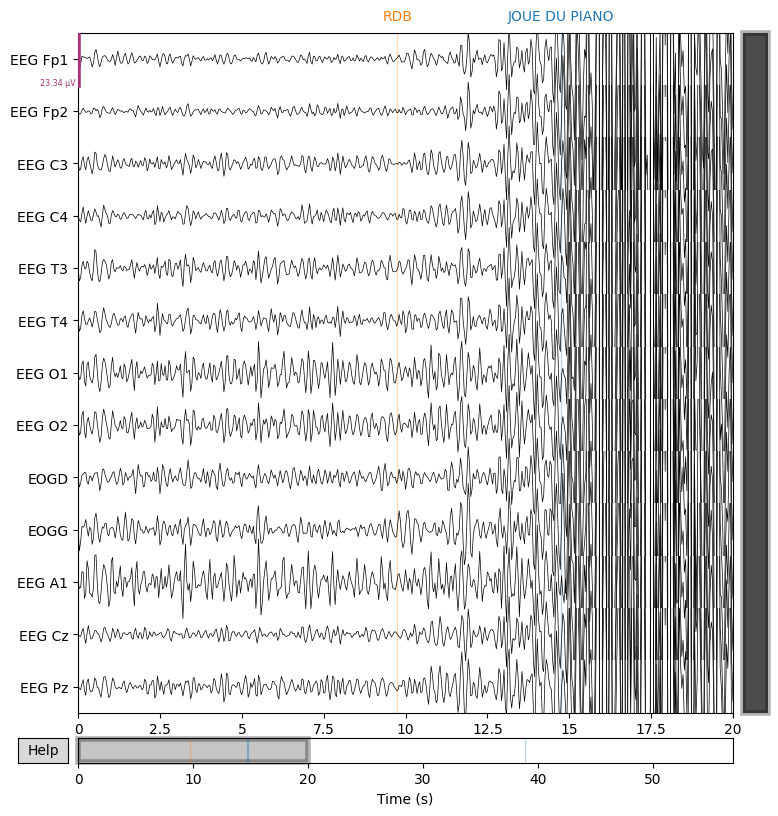

In [17]:
import mne
import os

fif_path = "../data/preprocessed/200924e-aex_0001_eeg_cleaned_raw.fif"  
l_freq, h_freq = 4, 8  # Bande alpha


raw = mne.io.read_raw_fif(fif_path, preload=True)
raw.pick_types(eeg=True)  

# Filtrage bande alpha
raw_alpha = raw.copy().filter(l_freq=l_freq, h_freq=h_freq)

# Affichage (10 premières secondes)
raw_alpha.plot(
    start=0,
    duration=20,
    scalings="auto",
    title=f"Bande alpha ({l_freq}-{h_freq} Hz)",
    show=False
)


### # REM detection (YASA librairie)

In [1]:
import yasa
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.filter import filter_data
sns.set_theme(font_scale=1.2)

Data loading : On plot le signal à la façon YASA

In [ ]:
import mne
import numpy as np
import yasa
import matplotlib.pyplot as plt
import seaborn as sns

# Charge fichier EDF avec MNE
raw = mne.io.read_raw_edf("D:/EEG/raw/AE129/AE129_231121C-A.edf", preload=True)
####""""#hjbhjjkbhhkbkjbkjnjkn"""
# Identifier et extraire les canaux EOG
eog_chans = [ch for ch in raw.ch_names if 'EOG' in ch.upper()]
if len(eog_chans) < 2:
    raise ValueError("Deux canaux EOG requis pour analyse phasique/tonique")


Extracting EDF parameters from D:\EEG\raw\AE129\AE129_231121C-A.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9428991  =      0.000 ... 36831.996 secs...


C:\Users\Dessalines\AppData\Local\Temp\ipykernel_26276\665720098.py:8: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf("D:/EEG/raw/AE129/AE129_231121C-A.edf", preload=True)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


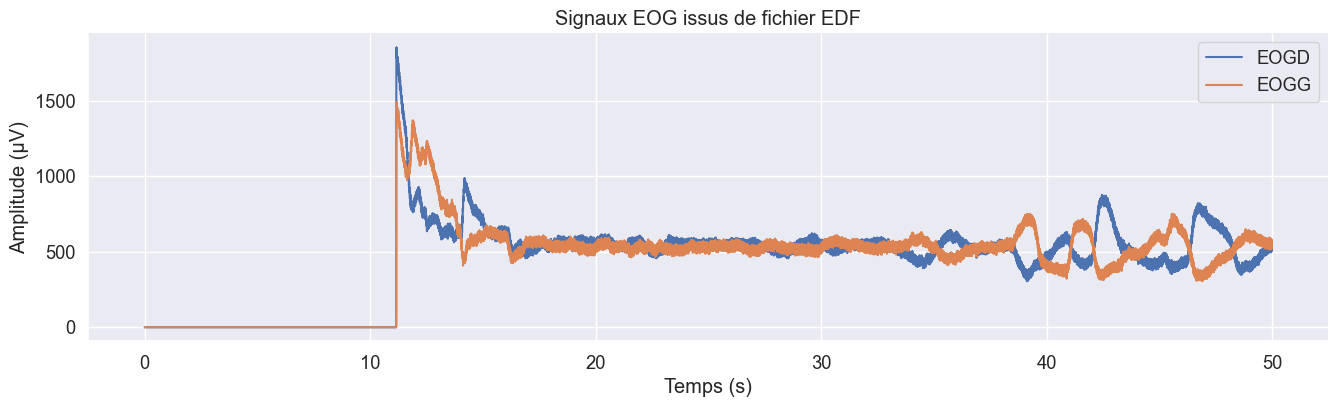

In [7]:

# Extraire les données sous forme NumPy
sf = raw.info['sfreq']
n_samples = int(50 * sf)

data = raw.copy().pick_channels(eog_chans).get_data()[:, :n_samples]

# Plot
times = np.arange(n_samples) / sf
plt.figure(figsize=(16, 4))
plt.plot(times, data[0] * 1e6, label=eog_chans[0])
plt.plot(times, data[1] * 1e6, label=eog_chans[1])
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude (µV)")
plt.title("Signaux EOG issus de fichier EDF")
plt.legend()
sns.despine()


In [9]:
from yasa import rem_detect

# Short version
# rem = rem_detect(loc, roc, sf)

# Long version (withh all optional, implicit, options)
loc =  data[0] * 1e6
roc =  data[1] * 1e6
rem = rem_detect(loc, roc, sf, hypno=None, include=4, amplitude=(50, 325), 
                 duration=(0.3, 1.5), freq_rem=(0.5, 5), remove_outliers=False, 
                 verbose=False)

# Get the detection dataframe
events = rem.summary()
events.round(3)

[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished


,Start,Peak,End,Duration,LOCAbsValPeak,ROCAbsValPeak,LOCAbsRiseSlope,ROCAbsRiseSlope,LOCAbsFallSlope,ROCAbsFallSlope
0,12.086,12.547,13.152,1.066,130.260,173.891,421.104,54.063,24.460,432.876
1,14.043,14.188,14.844,0.801,246.106,205.606,2280.962,493.817,309.890,324.202
2,33.840,34.473,35.129,1.289,50.056,52.627,64.472,92.763,87.775,62.522
3,35.129,35.621,36.316,1.188,66.143,51.981,119.055,129.173,99.491,65.525
4,38.633,39.160,39.738,1.105,105.372,143.595,229.093,247.387,126.850,373.680
5,40.105,40.855,41.074,0.969,90.473,124.548,114.204,21.357,365.423,630.800
6,41.074,41.738,42.133,1.059,150.990,164.248,243.240,227.100,283.968,487.487
7,42.133,42.438,43.188,1.055,225.600,123.241,868.284,312.322,317.746,110.816
8,45.316,45.730,46.395,1.078,87.532,133.408,205.035,325.167,90.869,233.590
9,46.395,46.684,47.434,1.039,167.785,132.986,674.506,384.955,148.608,126.369


### On va pouvoir passer à l'extraction des features !

### #)Etude des différents montages

In [2]:
! ls ../../documents/EEG/raw/

AD180	BJM190	CM161	DJ137	GS105	LF126	ML135	 PA139	 RJP148  TM151
AE129	BO60	CP155	DSJ112	GS191	LJ192	MM109	 PB186	 SB176	 TO145
AN166	BP185	CS131	EF130	GX111	LM183	MN143	 PF133	 SB178	 VA182
BA152	CA169	CS147	EP194	HG167	LS162	MP150	 PJC140  SD134	 VJ149
BA171	CB165	DA110	FP144	IS179	MA27	MP187	 PJL153  SJP172
BB114	CC175	DA174	FP52	JB173	MC154	MRM132	 RB103	 TG189
BDRE44	CD164	DBJ184	GD170	JLJ177	MFJ160	MS128	 RD158	 TJ127
BF181	CD28	DE188	GH163	JP141	MG16	NCJM193  RG156	 TLM168
BJ138	CJP53	DI136	GR108	KH113	MHTK39	NGA157	 RH146	 TM142


In [13]:
from pathlib import Path
import re
import pandas as pd
import mne

ROOT_DIR = Path("../../documents/EEG/raw/")  

# Si True, on ignore casse et espaces après suppression des préfixes (recommandé)
NORMALIZE_CASE_SPACE = True
PREFIXES_TO_STRIP = ("EEG ", "EOG ")
EDF_SUFFIXES = {".edf", ".EDF"}

def list_edf_files(root: Path):
    return [p for p in root.rglob("*") if p.suffix in EDF_SUFFIXES and p.is_file()]

def read_channels(path: Path):
    """Retourne (liste_canaux, erreur). Ne précharge pas les données."""
    try:
        raw = mne.io.read_raw_edf(str(path), preload=False, verbose="ERROR")
        return raw.ch_names, None
    except Exception as e:
        return None, f"{type(e).__name__}: {e}"

def strip_prefixes(name: str) -> str:
    """Supprime 'EEG ' et 'EOG ' au début (insensible à la casse), et trim."""
    s = name.lstrip()  # au cas où
    for pref in PREFIXES_TO_STRIP:
        if s.upper().startswith(pref.upper()):
            s = s[len(pref):]
            break
    return s.strip()

def normalize_name(name: str) -> str:
    """Normalise pour comparaison robuste si NORMALIZE_CASE_SPACE=True."""
    s = strip_prefixes(name)
    if NORMALIZE_CASE_SPACE:
        s = re.sub(r"\s+", " ", s.strip()).upper()
    return s

def get_patient_id(path: Path) -> str:
    """
    Heuristique simple : le dossier parent (ex. .../BO60/BO60_raw.edf -> 'BO60').
    Si besoin, on peut fallback sur le prefixe du nom de fichier avant '_raw'.
    """
    parent = path.parent.name
    if parent and parent != path.name:
        return parent
    # fallback si structure atypique
    stem = path.stem  # ex. "BO60_raw"
    m = re.match(r"([A-Za-z0-9]+)", stem)
    return m.group(1) if m else stem


In [14]:

files = list_edf_files(ROOT_DIR)
groups = {}          # key (tuple de canaux nettoyés) -> liste de patients
display_rows = []    # pour DataFrame détaillé
errors = []
patients_channels = {} 

for f in files:
    chs, err = read_channels(f)
    if chs is None:
        errors.append({"patient": get_patient_id(f), "file_path": str(f), "error": err})
        continue

    cleaned = [strip_prefixes(c) for c in chs]
    key = tuple(normalize_name(c) for c in chs)  # égalité sur version nettoyée (+ normalisée si activée)
    patient = get_patient_id(f)

    # Accumuler (union) les canaux normalisés par patient
    norm_set = {normalize_name(c) for c in chs}
    patients_channels.setdefault(patient, set()).update(norm_set)


    groups.setdefault(key, []).append(patient)
    display_rows.append({
        "patient": patient,
        "file_path": str(f),
        "n_channels": len(chs),
        "channels_cleaned": ", ".join(cleaned),
    })

# Tableau détaillé par fichier (avec canaux nettoyés pour inspection)
df = pd.DataFrame(display_rows, columns=["patient","file_path","n_channels","channels_cleaned"])
if not df.empty:
    df = df.sort_values(["n_channels", "patient"]).reset_index(drop=True)
display(df)

# Résumé : groupes de patients partageant exactement la même liste nettoyée
print("\n=== RÉSUMÉ : Groupes par liste de canaux (préfixes retirés{}normalisés) ===".format(
    ", casse/espaces " if NORMALIZE_CASE_SPACE else ", non normalisés "
))


,patient,file_path,n_channels,channels_cleaned
0,BJM190,../../documents/EEG/raw/BJM190/BJM190_raw.EDF,11,"E1-M2, E2-M2, EMG SUBMEN1, EMG SUBMEN2, F3-M2,..."
1,LJ192,../../documents/EEG/raw/LJ192/LJ192_raw.EDF,11,"E1-M2, E2-M2, EMG SUBMEN1, EMG SUBMEN2, F3-M2,..."
2,TG189,../../documents/EEG/raw/TG189/TG189_raw.EDF,11,"E1-M2, E2-M2, EMG SUBMEN1, EMG SUBMEN2, F3-M2,..."
3,DBJ184,../../documents/EEG/raw/DBJ184/DBJ184_raw.EDF,21,"C3, C4, F3, F4, M1, M2, O1, O2, ECG-LA, ECG-RA..."
4,LM183,../../documents/EEG/raw/LM183/LM183_raw.EDF,21,"C3, C4, F3, F4, M1, M2, O1, O2, ECG-LA, ECG-RA..."
...,...,...,...,...
74,MG16,../../documents/EEG/raw/MG16/MG16_raw.edf,38,"Fp1, Fp2, C3, C4, T3, T4, O1, O2, EOGD, EOGG, ..."
75,SB178,../../documents/EEG/raw/SB178/SB178_raw.edf,38,"Fp1, Fp2, C3, C4, T3, T4, O1, O2, EOGD, EOGG, ..."
76,SD134,../../documents/EEG/raw/SD134/SD134_raw.edf,38,"Fp1, Fp2, C3, C4, T3, T4, O1, O2, EOGD, EOGG, ..."
77,TJ127,../../documents/EEG/raw/TJ127/TJ127_raw.edf,38,"Fp1, Fp2, C3, C4, T3, T4, O1, O2, EOGD, EOGG, ..."



=== RÉSUMÉ : Groupes par liste de canaux (préfixes retirés, casse/espaces normalisés) ===


In [18]:

# Trier les groupes par taille décroissante
sorted_groups = sorted(groups.items(), key=lambda kv: len(kv[1]), reverse=True)

for idx, (key, patient_list) in enumerate(sorted_groups, start=1):
    uniq_patients = sorted(set(patient_list))
    print(f"\n--- Groupe #{idx} | {len(uniq_patients)} patient(s) | {len(key)} canaux ---")
    print("Liste des canaux :")
    print("  " + ", ".join(key))
    print("Patients :")
    for p in uniq_patients:
        print("  -", p)


# Affichage des erreurs de lecture s'il y en a
if errors:
    print("\n=== ERREURS DE LECTURE EDF ===")
    for e in errors:
        print(f"- {e['patient']} ({e['file_path']}) -> {e['error']}")




--- Groupe #1 | 56 patient(s) | 33 canaux ---
Liste des canaux :
  FP1, FP2, C3, C4, T3, T4, O1, O2, EOGD, EOGG, A1, MENTON, VTH, VAB, THERM, NAF2P, RONF, ECG, SAT, POS, PTT, PCO2, FC, POULS, JAMBG, JAMBD, EMG2, EMG1, CZ, PZ, SPO2_CAP, SLI, CPAP
Patients :
  - AE129
  - AN166
  - BA152
  - BA171
  - BB114
  - BF181
  - BJ138
  - BO60
  - CC175
  - CD28
  - CJP53
  - CP155
  - CS131
  - CS147
  - DA110
  - DA174
  - DI136
  - DJ137
  - DSJ112
  - EF130
  - FP144
  - GD170
  - GH163
  - GS191
  - GX111
  - HG167
  - JLJ177
  - JP141
  - LF126
  - MA27
  - MC154
  - MHTK39
  - ML135
  - MM109
  - MN143
  - MP150
  - MRM132
  - MS128
  - NGA157
  - PA139
  - PF133
  - PJC140
  - PJL153
  - RB103
  - RD158
  - RG156
  - RH146
  - RJP148
  - SB176
  - SJP172
  - TLM168
  - TM142
  - TM151
  - TO145
  - VA182
  - VJ149

--- Groupe #2 | 14 patient(s) | 38 canaux ---
Liste des canaux :
  FP1, FP2, C3, C4, T3, T4, O1, O2, EOGD, EOGG, A1, MENTON, VTH, VAB, NAF2P, RONF, ECG, SAT, POS, PTT, PCO2, 

In [43]:
# --- ÉLECTRODES COMMUNES À TOUS LES PATIENTS (hors certains groupes) ---
if patients_channels:
    GROUPS_TO_EXCLUDE = [2, 3, 4]  

    patients_to_exclude = set()
    for gi in GROUPS_TO_EXCLUDE:
        if gi < len(sorted_groups):
            patients_to_exclude.update(sorted_groups[gi][1])  # ajoute tous les patients de ce groupe
            print(f"Exclusion du groupe #{gi+1} avec {len(sorted_groups[gi][1])} patients.")

    # construire l'intersection en excluant ces patients
    iter_sets = (s for pid, s in patients_channels.items() if pid not in patients_to_exclude)
    try:
        common_excl = next(iter_sets).copy()
        for s in iter_sets:
            common_excl.intersection_update(s)

        print(f"\n=== ÉLECTRODES COMMUNES À TOUS LES PATIENTS (hors groupes {GROUPS_TO_EXCLUDE}) ({len(common_excl)}) ===")
        for ch in sorted(common_excl):
            print(" -", ch)
    except StopIteration:
        print("\nAucun patient restant après exclusion des groupes.")
else:
    print("\nAucun patient trouvé pour calculer les électrodes communes.")


Exclusion du groupe #3 avec 5 patients.
Exclusion du groupe #4 avec 3 patients.
Exclusion du groupe #5 avec 1 patients.

=== ÉLECTRODES COMMUNES À TOUS LES PATIENTS (hors groupes [2, 3, 4]) (29) ===
 - A1
 - C3
 - C4
 - CPAP
 - CZ
 - ECG
 - EOGD
 - EOGG
 - FC
 - FP1
 - FP2
 - JAMBD
 - MENTON
 - NAF2P
 - O1
 - O2
 - PCO2
 - POS
 - POULS
 - PTT
 - PZ
 - RONF
 - SAT
 - SLI
 - T3
 - T4
 - THERM
 - VAB
 - VTH


In [47]:
edf_path = "../../documents/EEG/raw/EP194/EP194_raw.EDF"  

raw = mne.io.read_raw_edf(edf_path, preload=True)
raw.plot(start=0, duration=10, scalings='auto', show=False)

Extracting EDF parameters from /home/darryld/documents/EEG/raw/EP194/EP194_raw.EDF...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


/tmp/ipykernel_3625132/2969759872.py:3: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw = mne.io.read_raw_edf(edf_path, preload=True)


IndexError: index -1 is out of bounds for axis 0 with size 0